# Module 7: Advanced Statistical Methods

### Course: R Programming - A Comprehensive Guide

**Author:** Kajola Gbenga
**Role:** Data Scientist & AI Engineer

---


## Learning Objectives

By the end of this notebook, you will be able to:

- Analyze and decompose time series data in R
- Apply forecasting techniques to time series data
- Perform Principal Component Analysis (PCA) for dimensionality reduction
- Perform cluster analysis to group similar observations
- Perform basic survival analysis
- Understand the foundations of machine learning concepts in R

## 1. Time Series Analysis

A time series is a sequence of observations recorded over time. R represents time series with the `ts()` object, which stores frequency (e.g. monthly, quarterly) and time span.

[1] "ts"

[1] 1949    1

[1] 1960   12

[1] 12

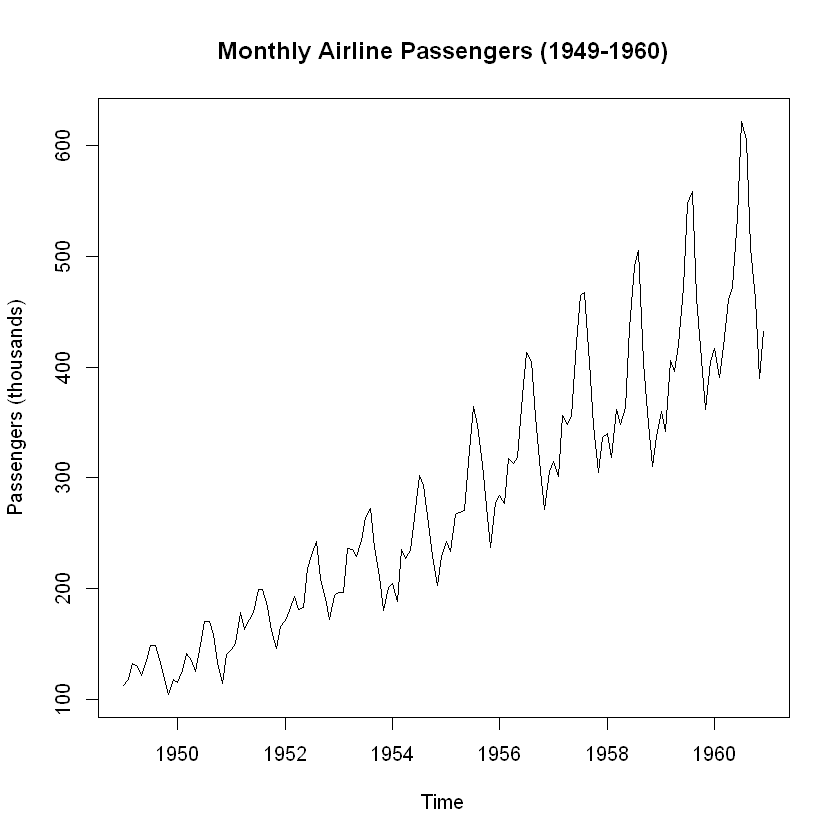

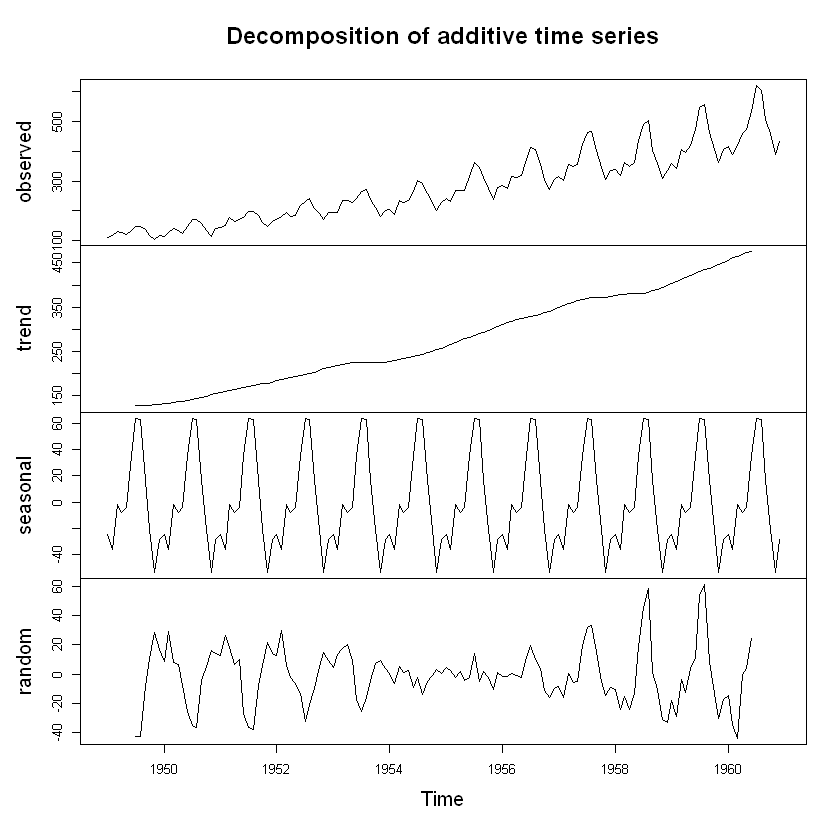

In [5]:
# Using the built in AirPassengers data set (monthly airline passengers)
data(AirPassengers)
ts_data <- AirPassengers

class(ts_data)
start(ts_data); end(ts_data); frequency(ts_data)

plot(ts_data, main = "Monthly Airline Passengers (1949-1960)", ylab = "Passengers (thousands)")

# Decomposition into trend, seasonal, and random components
decomposed <- decompose(ts_data)
plot(decomposed)


## 2. Forecasting Techniques

Common forecasting approaches in R include exponential smoothing (ETS) and ARIMA (AutoRegressive Integrated Moving Average) models, both available in the `forecast` package.

Series: ts_data 
ARIMA(2,1,1)(0,1,0)[12] 

Coefficients:
         ar1     ar2      ma1
      0.5960  0.2143  -0.9819
s.e.  0.0888  0.0880   0.0292

sigma^2 = 132.3:  log likelihood = -504.92
AIC=1017.85   AICc=1018.17   BIC=1029.35

Training set error measures:
                 ME     RMSE     MAE      MPE     MAPE     MASE        ACF1
Training set 1.3423 10.84619 7.86754 0.420698 2.800458 0.245628 -0.00124847

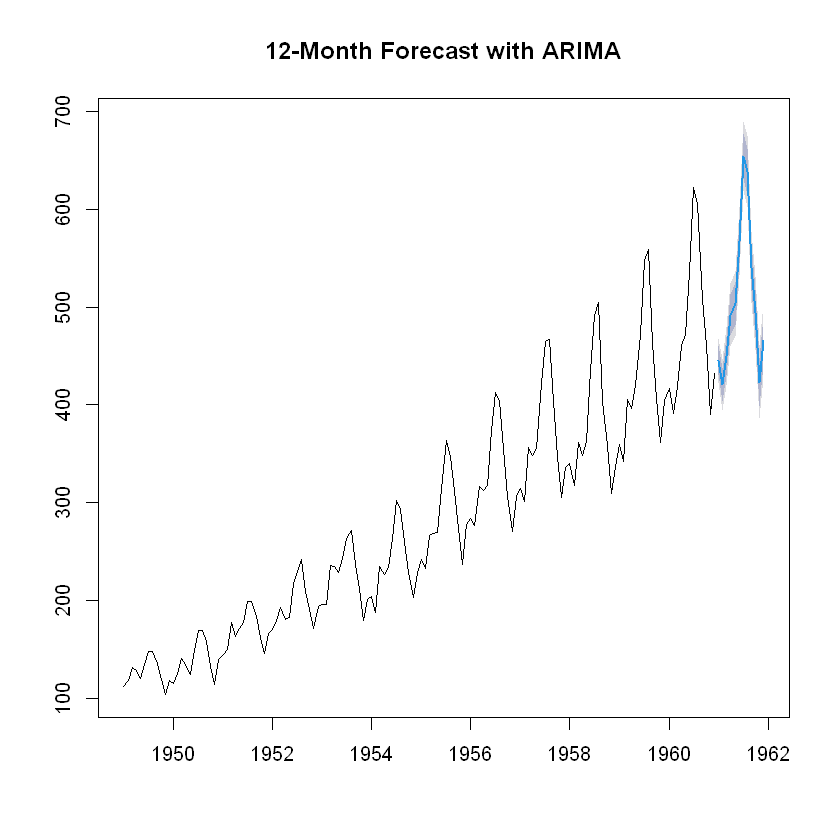

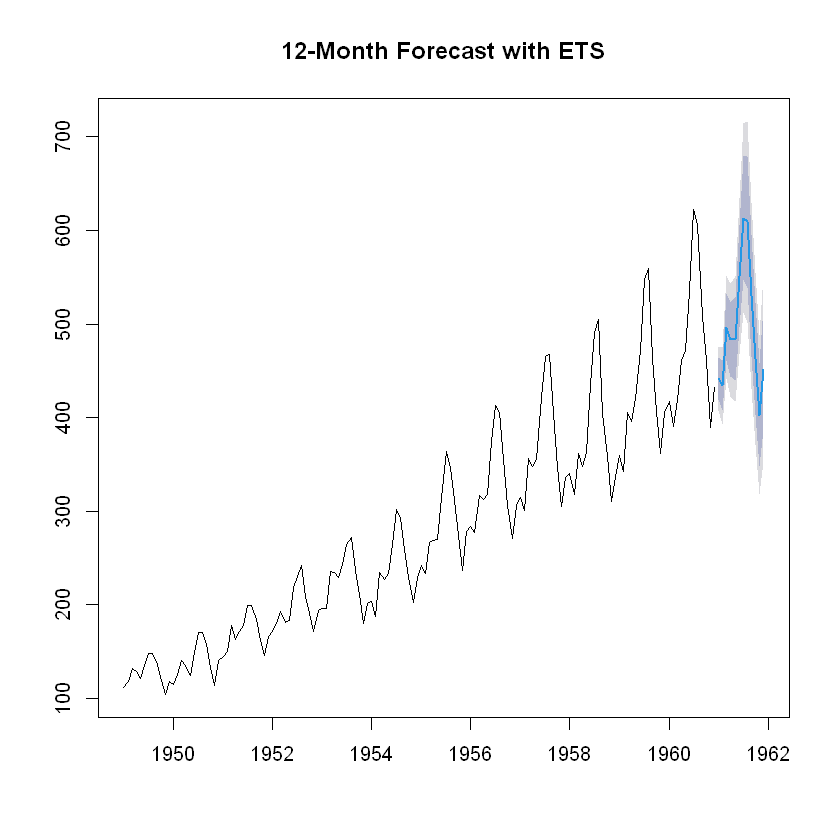

In [6]:
# install.packages("forecast")
library(forecast)

# ARIMA model
arima_model <- auto.arima(ts_data)
summary(arima_model)

arima_forecast <- forecast(arima_model, h = 12)   # forecast next 12 months
plot(arima_forecast, main = "12-Month Forecast with ARIMA")

# Exponential smoothing (ETS) model
ets_model <- ets(ts_data)
ets_forecast <- forecast(ets_model, h = 12)
plot(ets_forecast, main = "12-Month Forecast with ETS")


## 3. Principal Component Analysis (PCA)

PCA is a dimensionality reduction technique that transforms correlated variables into a smaller set of uncorrelated components that capture most of the variance in the data.

Importance of components:
                          PC1    PC2     PC3     PC4     PC5     PC6    PC7
Standard deviation     2.5707 1.6280 0.79196 0.51923 0.47271 0.46000 0.3678
Proportion of Variance 0.6008 0.2409 0.05702 0.02451 0.02031 0.01924 0.0123
Cumulative Proportion  0.6008 0.8417 0.89873 0.92324 0.94356 0.96279 0.9751
                           PC8    PC9    PC10   PC11
Standard deviation     0.35057 0.2776 0.22811 0.1485
Proportion of Variance 0.01117 0.0070 0.00473 0.0020
Cumulative Proportion  0.98626 0.9933 0.99800 1.0000

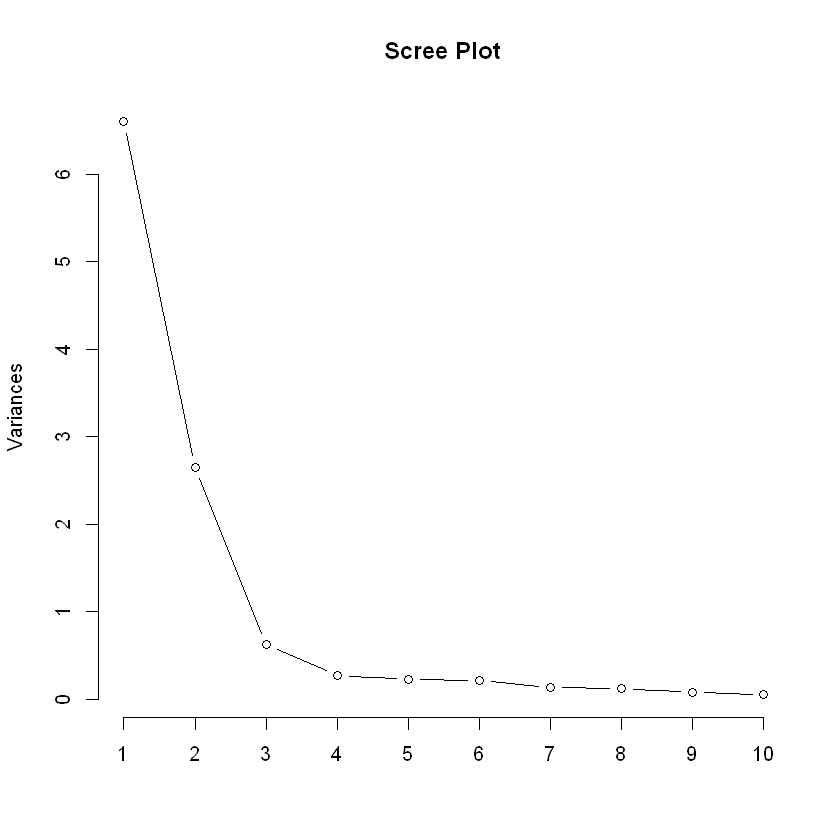

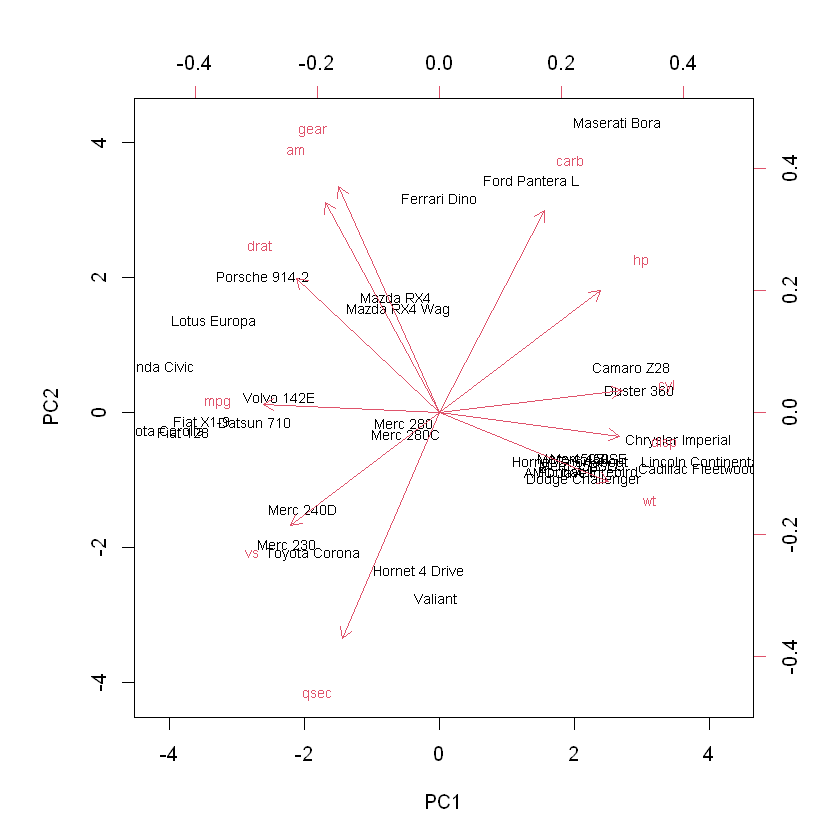

In [7]:
data(mtcars)

# Standardize variables before PCA (important because PCA is scale sensitive)
pca_result <- prcomp(mtcars, scale. = TRUE)
summary(pca_result)

# Variance explained by each component
screeplot(pca_result, type = "lines", main = "Scree Plot")

# Biplot showing observations and variable loadings together
biplot(pca_result, scale = 0, cex = 0.7)


## 4. Cluster Analysis

Cluster analysis groups similar observations together without using predefined labels. Two of the most common methods are:
- **K-means clustering**: partitions data into a chosen number of clusters (k)
- **Hierarchical clustering**: builds a tree (dendrogram) of nested clusters


Mazda RX4       Mazda RX4 Wag          Datsun 710      Hornet 4 Drive 
                  2                   2                   1                   1 
  Hornet Sportabout             Valiant          Duster 360           Merc 240D 
                  3                   1                   3                   1 
           Merc 230            Merc 280           Merc 280C          Merc 450SE 
                  1                   1                   1                   3 
         Merc 450SL         Merc 450SLC  Cadillac Fleetwood Lincoln Continental 
                  3                   3                   3                   3 
  Chrysler Imperial            Fiat 128         Honda Civic      Toyota Corolla 
                  3                   1                   1                   1 
      Toyota Corona    Dodge Challenger         AMC Javelin          Camaro Z28 
                  1                   3                   3                   3 
   Pontiac Firebird           Fiat X1-9       Porsche 914-2        Lotus Europa 
                  3                   1                   1                   1 
     Ford Pantera L        Ferrari Dino       Maserati Bora          Volvo 142E 
                  2                   2                   2                   1


 1  2  3 
15  5 12 

Warning message:
"package 'factoextra' was built under R version 4.5.3"
Loading required package: ggplot2

Warning message:
"package 'ggplot2' was built under R version 4.5.3"
Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/library/principal-component-methods



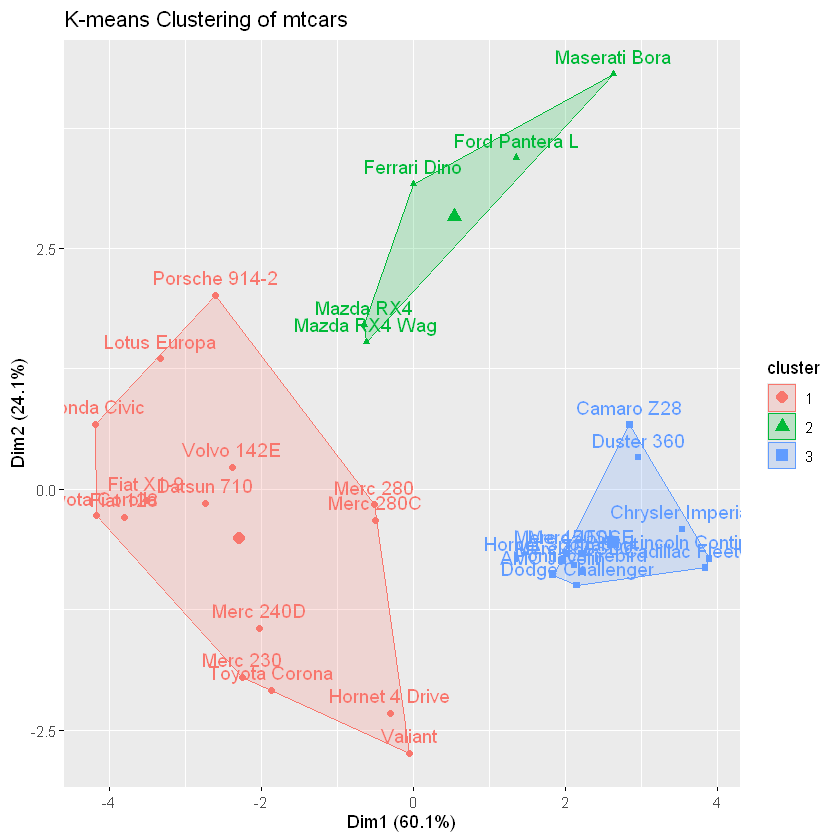

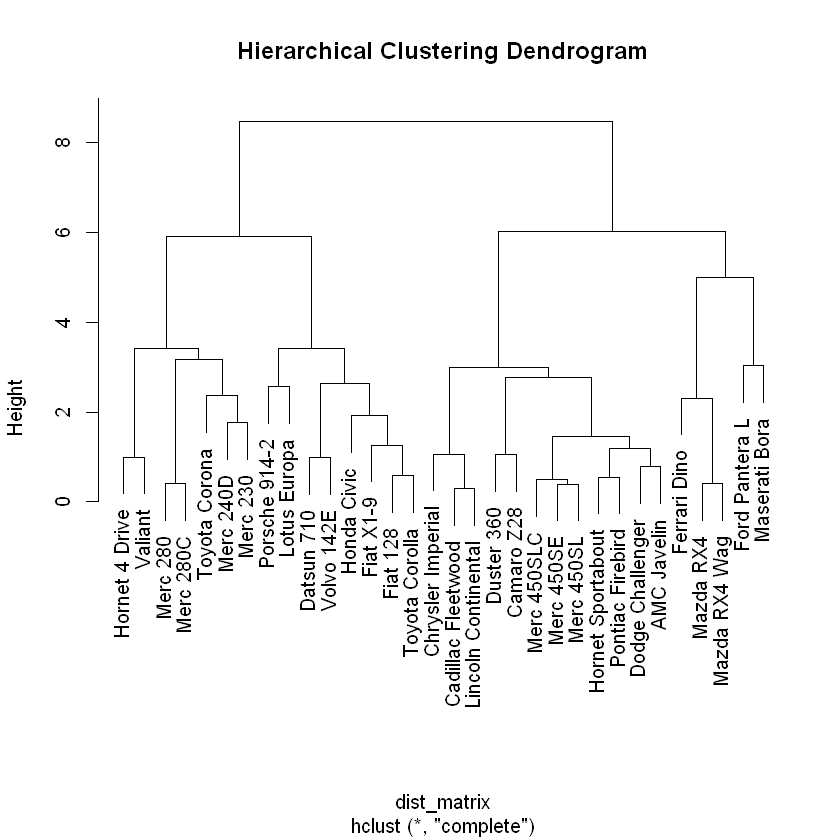

In [8]:
scaled_data <- scale(mtcars)

# ---- K-means clustering ----
set.seed(42)
km_result <- kmeans(scaled_data, centers = 3, nstart = 25)
km_result$cluster
table(km_result$cluster)

# Visualize clusters using the first two principal components
# install.packages("factoextra")
library(factoextra)
fviz_cluster(km_result, data = scaled_data, main = "K-means Clustering of mtcars")

# ---- Hierarchical clustering ----
dist_matrix <- dist(scaled_data)
hc_result <- hclust(dist_matrix, method = "complete")
plot(hc_result, main = "Hierarchical Clustering Dendrogram")


## 5. Survival Analysis

Survival analysis studies the time until an event of interest occurs (e.g. death, failure, churn). The `survival` package provides the core tools, including the Kaplan-Meier estimator for the survival function.

Warning message:
"package 'survival' was built under R version 4.5.3"
Warning message in data(lung):
"data set 'lung' not found"


,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3,306,2,74,1,1,90,100,1175,NA
2,3,455,2,68,1,0,90,90,1225,15
3,3,1010,1,56,1,0,90,90,NA,15
4,5,210,2,57,1,1,90,60,1150,11
5,1,883,2,60,1,0,100,90,NA,0
6,12,1022,1,74,1,1,50,80,513,0


Call: survfit(formula = surv_object ~ sex, data = lung)

                sex=1 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
   11    138       3   0.9783  0.0124       0.9542        1.000
   12    135       1   0.9710  0.0143       0.9434        0.999
   13    134       2   0.9565  0.0174       0.9231        0.991
   15    132       1   0.9493  0.0187       0.9134        0.987
   26    131       1   0.9420  0.0199       0.9038        0.982
   30    130       1   0.9348  0.0210       0.8945        0.977
   31    129       1   0.9275  0.0221       0.8853        0.972
   53    128       2   0.9130  0.0240       0.8672        0.961
   54    126       1   0.9058  0.0249       0.8583        0.956
   59    125       1   0.8986  0.0257       0.8496        0.950
   60    124       1   0.8913  0.0265       0.8409        0.945
   65    123       2   0.8768  0.0280       0.8237        0.933
   71    121       1   0.8696  0.0287       0.8152        0.928
   81    120       1   0

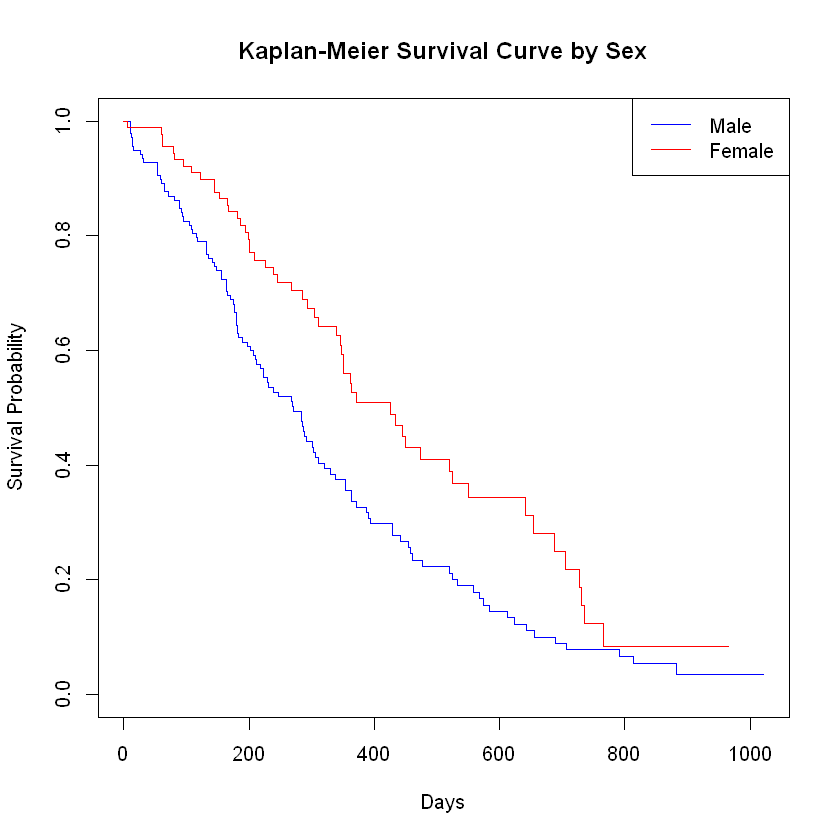

In [9]:
# install.packages("survival")
library(survival)

# Using the built in lung cancer data set
data(lung)
head(lung)

# Kaplan-Meier survival curve
surv_object <- Surv(time = lung$time, event = lung$status)
km_fit <- survfit(surv_object ~ sex, data = lung)
summary(km_fit)

plot(km_fit, col = c("blue", "red"), xlab = "Days", ylab = "Survival Probability",
     main = "Kaplan-Meier Survival Curve by Sex")
legend("topright", legend = c("Male", "Female"), col = c("blue", "red"), lty = 1)


## 6. Introduction to Machine Learning Concepts in R

R supports the full machine learning workflow, from data splitting to model training and evaluation. The `caret` package provides a unified interface across many algorithms.

Key concepts:
- **Training and test sets**: splitting data to evaluate generalization
- **Cross validation**: repeated train/test splits for a more robust performance estimate
- **Supervised learning**: regression and classification with labeled outcomes
- **Unsupervised learning**: clustering and PCA with no labeled outcome


In [ ]:
# install.packages("caret")
library(caret)

set.seed(123)
train_index <- createDataPartition(mtcars$mpg, p = 0.8, list = FALSE)
train_data <- mtcars[train_index, ]
test_data <- mtcars[-train_index, ]

# Train a simple linear model using caret with cross validation
train_control <- trainControl(method = "cv", number = 5)
ml_model <- train(mpg ~ wt + hp, data = train_data, method = "lm", trControl = train_control)
print(ml_model)

# Evaluate on the held out test set
predictions <- predict(ml_model, newdata = test_data)
postResample(predictions, test_data$mpg)


Warning message:
"package 'caret' was built under R version 4.5.3"
Loading required package: lattice


Attaching package: 'caret'


The following object is masked from 'package:survival':

    cluster




Linear Regression 

28 samples
 2 predictor

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 23, 23, 23, 21, 22 
Resampling results:

  RMSE      Rsquared   MAE     
  2.439465  0.8503618  2.022449

Tuning parameter 'intercept' was held constant at a value of TRUE


RMSE  Rsquared       MAE 
3.4390750 0.9508021 2.6610263

: 

## Practice Exercise

1. Decompose a time series data set into trend, seasonal, and residual components and interpret each.
2. Fit an ARIMA model and produce a 6 period forecast.
3. Run PCA on a numeric data set and determine how many components explain 90 percent of the variance.
4. Perform K-means clustering on a data set and visualize the resulting clusters.
5. Fit a Kaplan-Meier survival curve and interpret the differences between two groups.


---

## Module Summary

This notebook has walked through the core concepts, R code demonstrations, and practice exercises for this module. Review each section, run every code cell yourself, and attempt the practice exercises before moving to the next module.

**Kajola Gbenga**
Data Scientist & AI Engineer